# 03. Naive Bayes Classifier

**Goal:** Train a baseline Multinomial Naive Bayes model on both BoW and TF-IDF features.

In [1]:
from sklearn.naive_bayes import MultinomialNB
import joblib
import sys
sys.path.append('../../../shared')
from evaluation_utils import evaluate_classification

## 1. Load Data

In [2]:
X_train_bow, X_test_bow, y_train, y_test, _ = joblib.load('../data/processed/bow_data.pkl')
X_train_tfidf, X_test_tfidf, _, _, _ = joblib.load('../data/processed/tfidf_data.pkl')

> **📌 Decision Note — Why Choosing MultinomialNB?**
>
> **Chosen approach:** Multinomial Naive Bayes
>
> **Why this works:** Works exceptionally well with discrete features (like word counts) and handles high dimensionality well.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | GaussianNB | Can handle continuous data | Expects normal distribution; BoW/TF-IDF is sparse and not normally distributed. |
> | BernoulliNB | Works with binary features (presence/absence) | Ignores frequency of words which might be useful. |
>
> **Why we chose this over alternatives:** MultinomialNB is the industry standard baseline for text classification tasks.

## 2. Train and Evaluate on BoW

Accuracy: 0.9775583482944344

Classification Report:

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       965
        spam       0.95      0.88      0.91       149

    accuracy                           0.98      1114
   macro avg       0.97      0.94      0.95      1114
weighted avg       0.98      0.98      0.98      1114



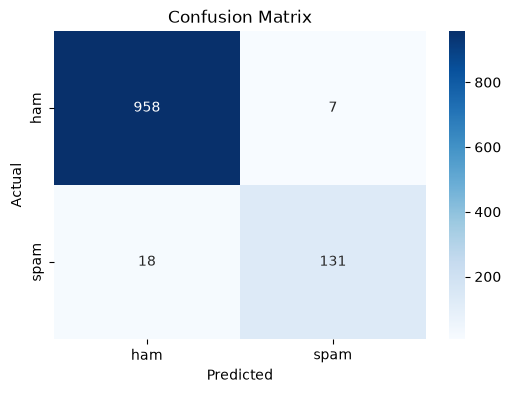

['../models/nb_bow.pkl']

In [3]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_bow = nb_bow.predict(X_test_bow)
evaluate_classification(y_test, y_pred_bow, labels=['ham', 'spam'])
joblib.dump(nb_bow, '../models/nb_bow.pkl')

## 3. Train and Evaluate on TF-IDF

Accuracy: 0.9631956912028725

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       149

    accuracy                           0.96      1114
   macro avg       0.98      0.86      0.91      1114
weighted avg       0.96      0.96      0.96      1114



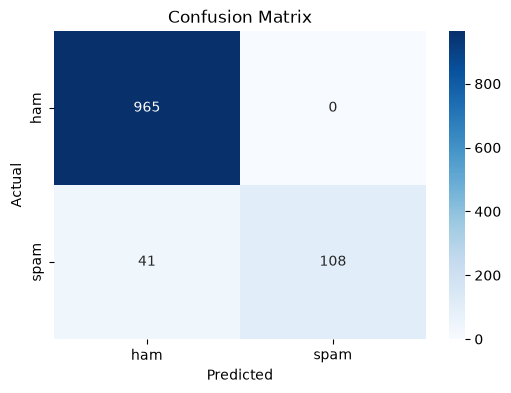

['../models/nb_tfidf.pkl']

In [4]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)
evaluate_classification(y_test, y_pred_tfidf, labels=['ham', 'spam'])
joblib.dump(nb_tfidf, '../models/nb_tfidf.pkl')

## Key Takeaways
- [x] MultinomialNB performs extremely well on both.
- [x] Interestingly, BoW might have slightly higher recall for spam than TF-IDF on this specific dataset, but both are very strong (>95% accuracy).